# Water Quality Analysis & Hypoxia Risk Classification

**Project ini menganalisis data monitoring kualitas air (1989–2019)** dari 5 lokasi pemantauan, lalu membangun model klasifikasi untuk memprediksi **risiko hipoksia (kekurangan oksigen terlarut/Dissolved Oxygen)** berdasarkan parameter kualitas air, lokasi, dan musim.

**Alur project:**
1. Data Reading
2. Data Exploration (EDA)
3. Data Cleaning
4. Exploratory Visualization
5. Feature Engineering & Target Definition
6. Machine Learning Modeling (dengan perbandingan model & cross-validation)
7. Model Evaluation
8. Kesimpulan & Insight

---


## 1. Data Reading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, accuracy_score, precision_score, recall_score, f1_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [2]:
# Membaca dataset dengan encoding utf-8 agar simbol derajat (°) terbaca dengan benar
df = pd.read_csv("Water_Quality.csv", encoding="utf-8")

# Merapikan nama kolom yang rusak karena encoding (°C/°F terbaca sebagai ?C/?F)
df.columns = df.columns.str.replace("?C", "C", regex=False).str.replace("?F", "F", regex=False)
df.columns


Index(['Site_Id', 'Unit_Id', 'Read_Date', 'Salinity (ppt)',
       'Dissolved Oxygen (mg/L)', 'pH (standard units)', 'Secchi Depth (m)',
       'Water Depth (m)', 'Water Temp (C)', 'Air Temp-Celsius', 'Air Temp (F)',
       'Time (24:00)', 'Field_Tech', 'DateVerified', 'WhoVerified',
       'AirTemp (C)', 'Year'],
      dtype='str')

## 2. Data Exploration (EDA)

Sebelum membersihkan data, kita eksplorasi dulu untuk memahami struktur, kualitas, dan pola pada data.

In [3]:
df.head()

,Site_Id,Unit_Id,Read_Date,Salinity (ppt),Dissolved Oxygen (mg/L),pH (standard units),Secchi Depth (m),Water Depth (m),Water Temp (C),Air Temp-Celsius,Air Temp (F),Time (24:00),Field_Tech,DateVerified,WhoVerified,AirTemp (C),Year
0,Bay,NaN,1/3/1994,1.3,11.7,7.3,0.40,0.40,5.9,8.0,46.40,11:00,NaN,NaN,NaN,8.0,1994
1,Bay,NaN,1/31/1994,1.5,12.0,7.4,0.20,0.35,3.0,2.6,36.68,11:30,NaN,NaN,NaN,2.6,1994
2,Bay,NaN,2/7/1994,1.0,10.5,7.2,0.25,0.60,5.9,7.6,45.68,9:45,NaN,NaN,NaN,7.6,1994
3,Bay,NaN,2/23/1994,1.0,10.1,7.4,0.35,0.50,10.0,2.7,36.86,NaN,NaN,NaN,NaN,2.7,1994
4,Bay,NaN,2/28/1994,1.0,12.6,7.2,0.20,0.40,1.6,0.0,32.00,10:30,NaN,NaN,NaN,0.0,1994


In [4]:
df.shape

(2371, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Site_Id                  2370 non-null   str    
 1   Unit_Id                  32 non-null     str    
 2   Read_Date                2366 non-null   str    
 3   Salinity (ppt)           2241 non-null   float64
 4   Dissolved Oxygen (mg/L)  1520 non-null   float64
 5   pH (standard units)      2276 non-null   float64
 6   Secchi Depth (m)         2298 non-null   float64
 7   Water Depth (m)          2300 non-null   float64
 8   Water Temp (C)           2250 non-null   float64
 9   Air Temp-Celsius         85 non-null     float64
 10  Air Temp (F)             2300 non-null   float64
 11  Time (24:00)             2308 non-null   str    
 12  Field_Tech               2332 non-null   str    
 13  DateVerified             453 non-null    str    
 14  WhoVerified              453 non-nu

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct (%)": missing_pct}).sort_values("missing_pct (%)", ascending=False)


,missing_count,missing_pct (%)
Unit_Id,2339,98.65
Air Temp-Celsius,2286,96.42
DateVerified,1918,80.89
WhoVerified,1918,80.89
Dissolved Oxygen (mg/L),851,35.89
Salinity (ppt),130,5.48
Water Temp (C),121,5.10
pH (standard units),95,4.01
Secchi Depth (m),73,3.08
Air Temp (F),71,2.99


In [7]:
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


### Cek konsistensi kategori `Site_Id`

Ditemukan inkonsistensi penulisan (`D` dan `d` tercatat sebagai dua site berbeda, padahal merujuk lokasi yang sama).

In [8]:
print("Sebelum dibersihkan:", df["Site_Id"].unique())

df["Site_Id"] = df["Site_Id"].str.strip().str.upper()

print("Setelah dibersihkan:", df["Site_Id"].unique())
df["Site_Id"].value_counts()


Sebelum dibersihkan: <StringArray>
['Bay', 'A', 'B', 'C', 'D', 'd', nan]
Length: 7, dtype: str
Setelah dibersihkan: <StringArray>
['BAY', 'A', 'B', 'C', 'D', nan]
Length: 6, dtype: str


Site_Id
BAY    794
D      441
B      437
A      434
C      264
Name: count, dtype: int64

In [9]:
df.describe()

,Salinity (ppt),Dissolved Oxygen (mg/L),pH (standard units),Secchi Depth (m),Water Depth (m),Water Temp (C),Air Temp-Celsius,Air Temp (F),AirTemp (C),Year
count,2241.000000,1520.000000,2276.000000,2298.000000,2300.000000,2250.000000,85.000000,2300.000000,2371.000000,2371.000000
mean,0.717068,6.646263,7.168212,0.524898,0.762559,18.062138,16.437647,62.051637,15.663050,2006.049346
std,1.230819,2.506608,0.788485,0.473663,0.621140,8.298246,11.754138,15.492236,10.314720,9.002373
min,0.000000,0.000000,0.300000,0.000000,0.010000,0.000000,0.000000,10.500000,-17.777778,1899.000000
25%,0.000000,4.800000,6.500000,0.300000,0.400000,11.000000,9.000000,49.000000,8.888889,2001.000000
50%,0.000000,6.500000,7.000000,0.400000,0.650000,19.000000,15.000000,63.000000,16.666667,2007.000000
75%,1.000000,8.500000,7.500000,0.650000,0.950000,25.000000,21.700000,75.000000,23.888889,2012.000000
max,9.000000,15.100000,9.900000,9.000000,12.000000,74.000000,74.000000,92.300000,33.500000,2019.000000


### Cek skewness setiap kolom numerik

Ini penting untuk menentukan strategi imputasi missing value yang tepat: **mean** untuk distribusi yang relatif simetris, **median** untuk distribusi yang skewed (agar tidak bias oleh outlier).

In [10]:
num_cols = ["Salinity (ppt)", "Dissolved Oxygen (mg/L)", "pH (standard units)",
            "Secchi Depth (m)", "Water Depth (m)", "Water Temp (C)", "Air Temp (F)"]

skewness = df[num_cols].skew().sort_values(key=abs, ascending=False)
skewness


Secchi Depth (m)           7.060480
Water Depth (m)            6.193840
Salinity (ppt)             1.972846
Air Temp (F)              -0.359266
pH (standard units)        0.269657
Dissolved Oxygen (mg/L)    0.185227
Water Temp (C)             0.139022
dtype: float64

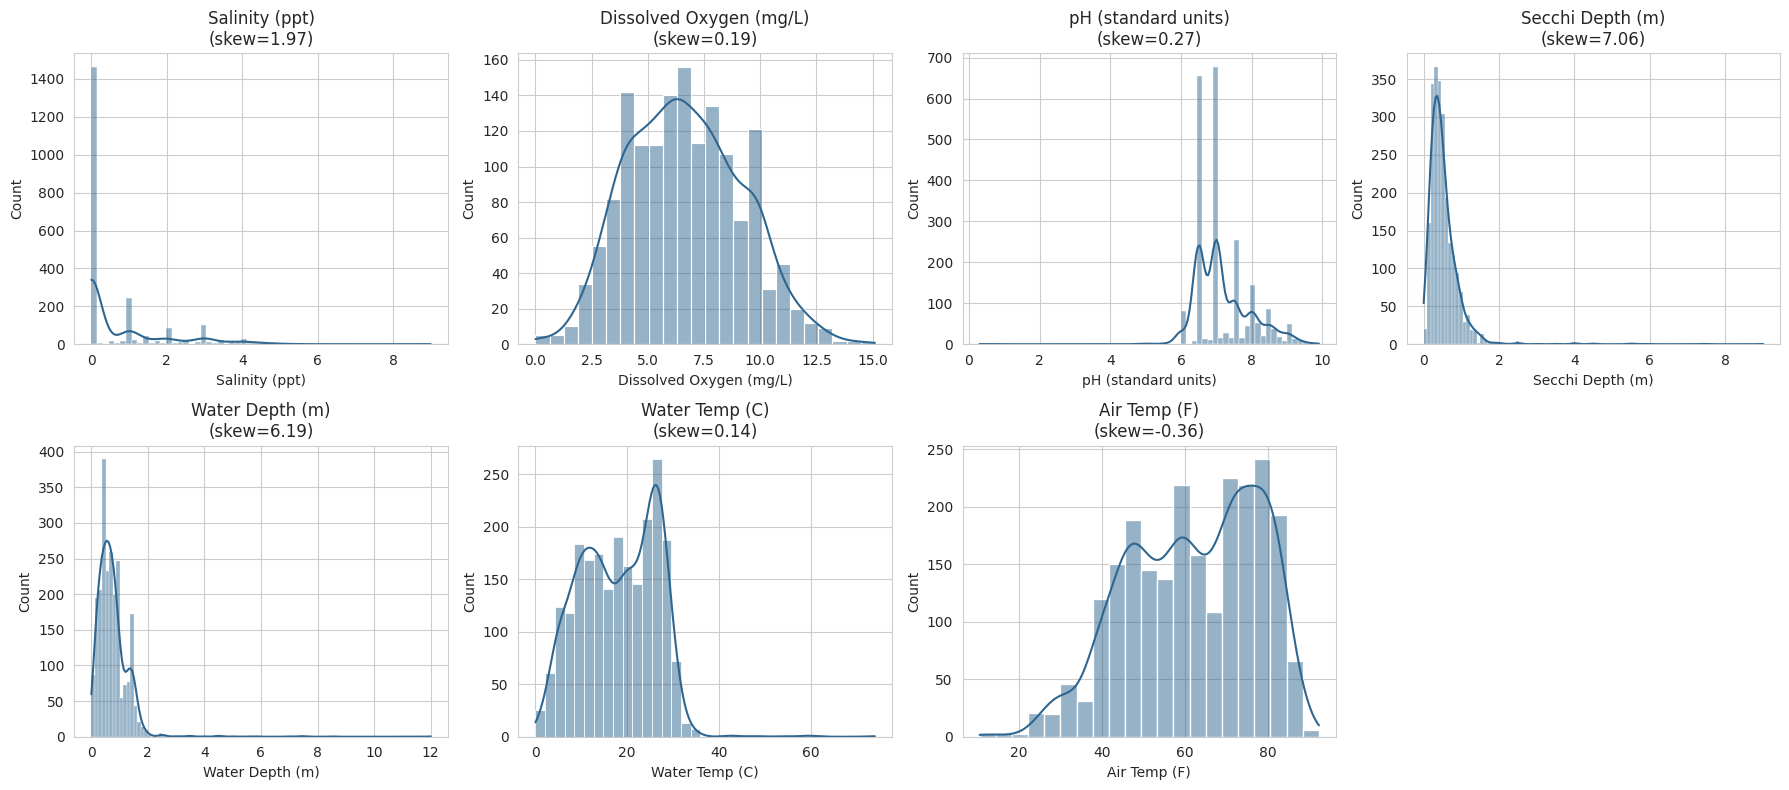

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#2f6690")
    axes[i].set_title(f"{col}\n(skew={df[col].skew():.2f})")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Insight:**
- `Secchi Depth (m)` dan `Salinity (ppt)` sangat **skewed** (banyak nilai 0 / dekat 0) → gunakan **median** untuk imputasi.
- `pH`, `Water Temp`, `Air Temp` relatif **simetris** → gunakan **mean** untuk imputasi.
- `Dissolved Oxygen (mg/L)` memiliki missing value besar (~36%) — kolom ini adalah **variabel target** pada project ini, sehingga baris tanpa nilai DO tidak akan diimputasi, melainkan dikeluarkan dari proses modeling (imputasi pada target akan mencemari label dengan asumsi, bukan observasi nyata).


## 3. Data Cleaning

**Prinsip cleaning yang diterapkan:**
- Imputasi mean/median untuk fitur didasarkan pada skewness masing-masing kolom.
- Kolom `AirTemp (C)` (0% missing) dipertahankan sebagai referensi eksplorasi, sedangkan `Air Temp-Celsius` (96% missing) di-drop karena datanya nyaris seluruhnya kosong.
- `Dissolved Oxygen (mg/L)` — sebagai calon target — **tidak diimputasi sama sekali**, untuk menjaga integritas label.
- `Read_Date` dikonversi ke datetime, dan fitur musiman (`Month`) diekstrak untuk membantu prediksi.


In [12]:
# Imputasi berbasis median (untuk kolom skewed) - hanya untuk fitur, bukan target
median_cols = ["Salinity (ppt)", "Secchi Depth (m)"]
for c in median_cols:
    df[c] = df[c].fillna(df[c].median())

# Imputasi berbasis mean (untuk kolom fitur yang relatif simetris)
mean_cols = ["pH (standard units)", "Water Temp (C)", "Air Temp (F)", "Water Depth (m)"]
for c in mean_cols:
    df[c] = df[c].fillna(df[c].mean())

# Dissolved Oxygen SENGAJA tidak diimputasi karena akan dijadikan target klasifikasi


In [13]:
# Baris tanpa tanggal tidak berguna untuk analisis tren waktu -> drop
df.dropna(subset=["Read_Date"], inplace=True)

# Kolom dengan missing value sangat besar & tidak esensial -> drop
df.drop(columns=["Unit_Id", "Air Temp-Celsius",
                  "Field_Tech", "DateVerified", "WhoVerified"], inplace=True)


In [14]:
df["Read_Date"] = pd.to_datetime(df["Read_Date"])
df["Month"] = df["Read_Date"].dt.month
df["Season"] = df["Month"] % 12 // 3 + 1  # 1=Winter,2=Spring,3=Summer,4=Fall (Northern Hemisphere)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()


,Site_Id,Read_Date,Salinity (ppt),Dissolved Oxygen (mg/L),pH (standard units),Secchi Depth (m),Water Depth (m),Water Temp (C),Air Temp (F),Time (24:00),AirTemp (C),Year,Month,Season
0,BAY,1994-01-03,1.3,11.7,7.3,0.40,0.40,5.9,46.40,11:00,8.0,1994,1,1
1,BAY,1994-01-31,1.5,12.0,7.4,0.20,0.35,3.0,36.68,11:30,2.6,1994,1,1
2,BAY,1994-02-07,1.0,10.5,7.2,0.25,0.60,5.9,45.68,9:45,7.6,1994,2,1
3,BAY,1994-02-23,1.0,10.1,7.4,0.35,0.50,10.0,36.86,NaN,2.7,1994,2,1
4,BAY,1994-02-28,1.0,12.6,7.2,0.20,0.40,1.6,32.00,10:30,0.0,1994,2,1


In [15]:
print("Ukuran data setelah cleaning:", df.shape)
df.isnull().sum()


Ukuran data setelah cleaning: (2364, 14)


Site_Id                      0
Read_Date                    0
Salinity (ppt)               0
Dissolved Oxygen (mg/L)    845
pH (standard units)          0
Secchi Depth (m)             0
Water Depth (m)              0
Water Temp (C)               0
Air Temp (F)                 0
Time (24:00)                61
AirTemp (C)                  0
Year                         0
Month                        0
Season                       0
dtype: int64

## 4. Exploratory Visualization

### Tren rata-rata Dissolved Oxygen & suhu air per tahun

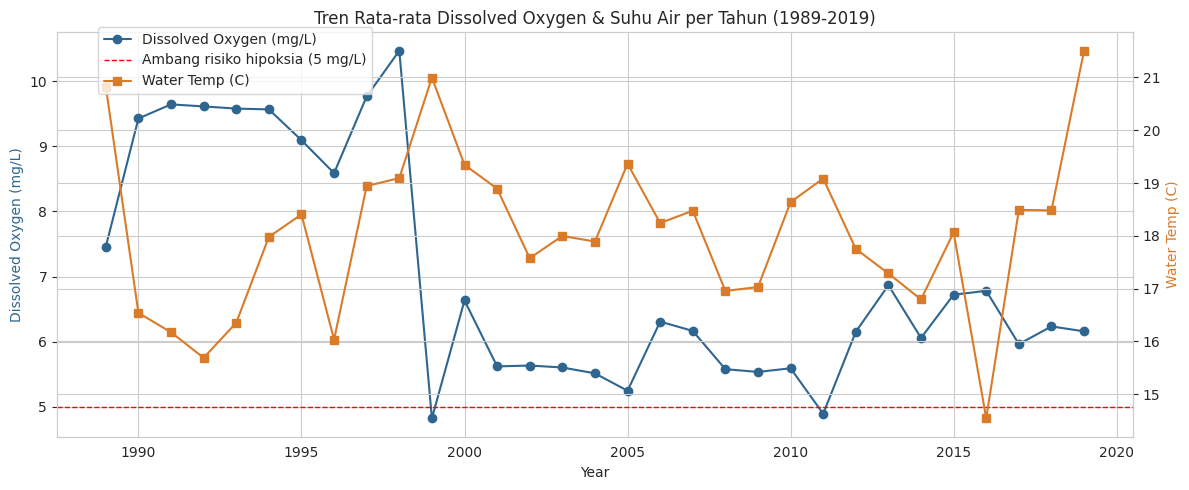

In [16]:
yearly = df.groupby("Year")[["Dissolved Oxygen (mg/L)", "Water Temp (C)"]].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(yearly.index, yearly["Dissolved Oxygen (mg/L)"], color="#2f6690", marker="o", label="Dissolved Oxygen (mg/L)")
ax1.axhline(5, color="red", linestyle="--", linewidth=1, label="Ambang risiko hipoksia (5 mg/L)")
ax1.set_ylabel("Dissolved Oxygen (mg/L)", color="#2f6690")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly["Water Temp (C)"], color="#d97b29", marker="s", label="Water Temp (C)")
ax2.set_ylabel("Water Temp (C)", color="#d97b29")

fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.95))
plt.title("Tren Rata-rata Dissolved Oxygen & Suhu Air per Tahun (1989-2019)")
fig.tight_layout()
plt.show()


### Distribusi Dissolved Oxygen dengan ambang batas risiko hipoksia

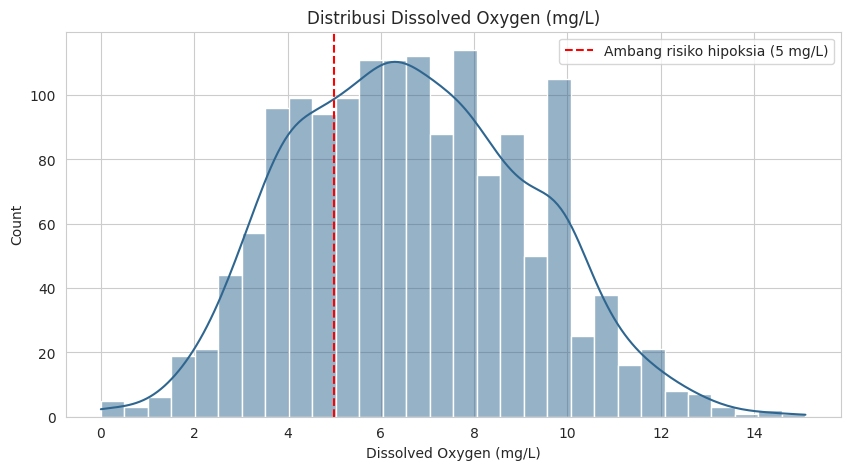

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Dissolved Oxygen (mg/L)"].dropna(), kde=True, color="#2f6690", bins=30)
plt.axvline(5, color="red", linestyle="--", label="Ambang risiko hipoksia (5 mg/L)")
plt.legend()
plt.title("Distribusi Dissolved Oxygen (mg/L)")
plt.show()


### Dissolved Oxygen per site & hubungannya dengan suhu air

/tmp/ipykernel_475/4241960493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Site_Id", y="Dissolved Oxygen (mg/L)", ax=axes[0], palette="Blues")


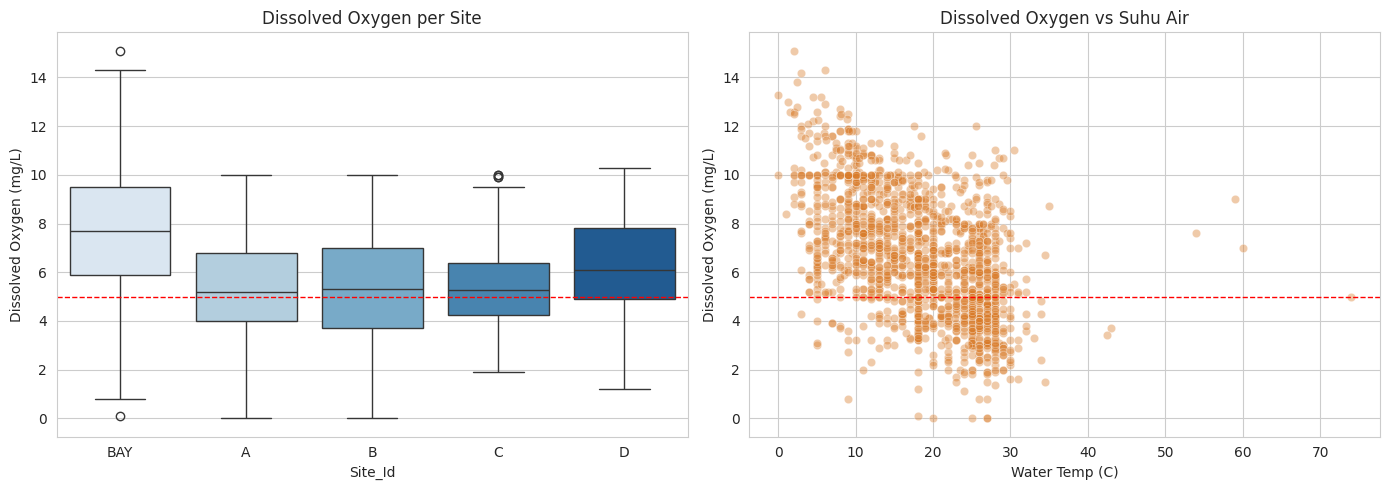

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Site_Id", y="Dissolved Oxygen (mg/L)", ax=axes[0], palette="Blues")
axes[0].axhline(5, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Dissolved Oxygen per Site")

sns.scatterplot(data=df, x="Water Temp (C)", y="Dissolved Oxygen (mg/L)", alpha=0.4, ax=axes[1], color="#d97b29")
axes[1].axhline(5, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Dissolved Oxygen vs Suhu Air")

plt.tight_layout()
plt.show()


### Correlation heatmap antar variabel numerik

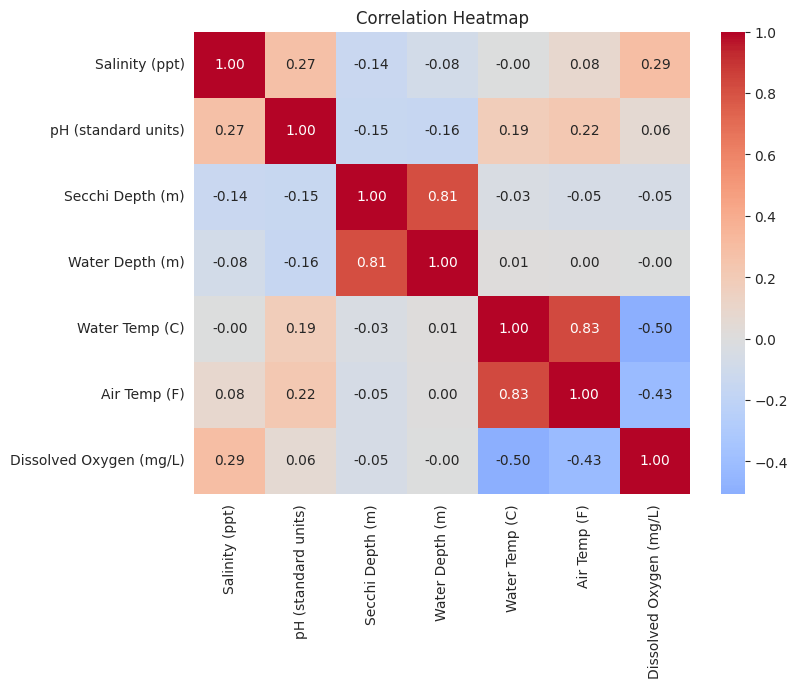

In [19]:
corr_cols = ["Salinity (ppt)", "pH (standard units)", "Secchi Depth (m)",
             "Water Depth (m)", "Water Temp (C)", "Air Temp (F)", "Dissolved Oxygen (mg/L)"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Heatmap")
plt.show()


**Insight dari visualisasi:** Dissolved Oxygen berkorelasi negatif cukup kuat dengan suhu air — semakin hangat air, semakin rendah kadar oksigen terlarutnya. Pola ini konsisten di seluruh site, dan menjadi dasar kenapa suhu air (beserta musim) menjadi fitur penting dalam memprediksi risiko hipoksia.

## 5. Feature Engineering & Target Definition

**Mendefinisikan target klasifikasi: Risiko Hipoksia**

Ambang batas **5 mg/L** digunakan sebagai batas bawah kadar oksigen terlarut yang umum dipakai dalam standar pemantauan kualitas air untuk mendukung kehidupan akuatik (di bawah ambang ini, banyak biota air mulai mengalami stres oksigen). Baris dengan DO < 5 mg/L diberi label **1 (Berisiko)**, selebihnya **0 (Aman)**.

Hanya baris dengan nilai DO yang benar-benar terukur (bukan hasil imputasi) yang digunakan untuk modeling, agar label mencerminkan observasi nyata di lapangan.

In [20]:
df_model = df.dropna(subset=["Dissolved Oxygen (mg/L)"]).copy()

df_model["Risiko_Hipoksia"] = (df_model["Dissolved Oxygen (mg/L)"] < 5).astype(int)

print("Jumlah baris untuk modeling:", df_model.shape[0])
print()
print(df_model["Risiko_Hipoksia"].value_counts())
print()
print("Proporsi kelas (%):")
print(df_model["Risiko_Hipoksia"].value_counts(normalize=True) * 100)


Jumlah baris untuk modeling: 1519

Risiko_Hipoksia
0    1110
1     409
Name: count, dtype: int64

Proporsi kelas (%):
Risiko_Hipoksia
0    73.074391
1    26.925609
Name: proportion, dtype: float64


/tmp/ipykernel_475/3398054935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_model, x="Risiko_Hipoksia", palette=["#2f6690", "#d94f4f"])


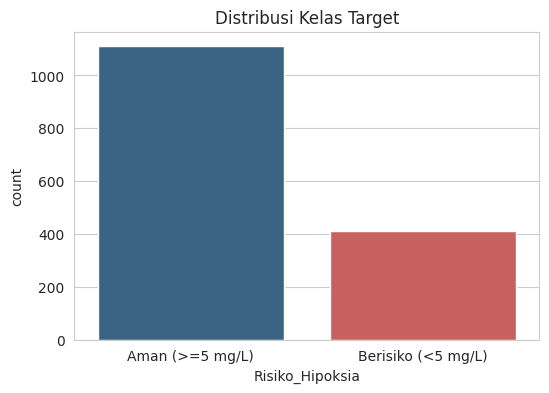

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_model, x="Risiko_Hipoksia", palette=["#2f6690", "#d94f4f"])
plt.xticks([0, 1], ["Aman (>=5 mg/L)", "Berisiko (<5 mg/L)"])
plt.title("Distribusi Kelas Target")
plt.show()


In [22]:
features = ["pH (standard units)", "Salinity (ppt)", "Secchi Depth (m)",
            "Water Depth (m)", "Water Temp (C)", "Month"]

df_encoded = pd.get_dummies(df_model[features + ["Site_Id"]], columns=["Site_Id"], prefix="Site")

X = df_encoded
y = df_model["Risiko_Hipoksia"]

X.head()


,pH (standard units),Salinity (ppt),Secchi Depth (m),Water Depth (m),Water Temp (C),Month,Site_A,Site_B,Site_BAY,Site_C,Site_D
0,7.3,1.3,0.40,0.40,5.9,1,False,False,True,False,False
1,7.4,1.5,0.20,0.35,3.0,1,False,False,True,False,False
2,7.2,1.0,0.25,0.60,5.9,2,False,False,True,False,False
3,7.4,1.0,0.35,0.50,10.0,2,False,False,True,False,False
4,7.2,1.0,0.20,0.40,1.6,2,False,False,True,False,False


## 6. Machine Learning Modeling

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit HANYA di data train
X_test_scaled = scaler.transform(X_test)          # test set cukup di-transform


### Perbandingan 2 model: Logistic Regression vs Random Forest Classifier

Data target sedikit tidak seimbang (kelas "Berisiko" lebih sedikit), sehingga evaluasi tidak cukup hanya dengan akurasi — precision, recall, F1, dan ROC-AUC dipakai agar performa terhadap kelas minoritas (kasus berisiko, yang justru paling penting dideteksi) benar-benar terukur.

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=300, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="roc_auc")

    results[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1,
        "ROC-AUC": roc_auc, "CV ROC-AUC (mean)": cv_scores.mean(), "CV ROC-AUC (std)": cv_scores.std(),
        "y_pred": y_pred, "y_proba": y_proba
    }

results_df = pd.DataFrame(results).T.drop(columns=["y_pred", "y_proba"])
results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV ROC-AUC (mean),CV ROC-AUC (std)
Logistic Regression,0.773026,0.618182,0.414634,0.49635,0.785761,0.82475,0.025788
Random Forest Classifier,0.799342,0.652174,0.54878,0.596026,0.82806,0.838967,0.025557


## 7. Model Evaluation

In [25]:
best_model_name = results_df["CV ROC-AUC (mean)"].astype(float).idxmax()
print("Model terbaik berdasarkan cross-validation ROC-AUC:", best_model_name)

y_pred_best = results[best_model_name]["y_pred"]
y_proba_best = results[best_model_name]["y_proba"]

print()
print(classification_report(y_test, y_pred_best, target_names=["Aman", "Berisiko"]))


Model terbaik berdasarkan cross-validation ROC-AUC: Random Forest Classifier

              precision    recall  f1-score   support

        Aman       0.84      0.89      0.87       222
    Berisiko       0.65      0.55      0.60        82

    accuracy                           0.80       304
   macro avg       0.75      0.72      0.73       304
weighted avg       0.79      0.80      0.79       304



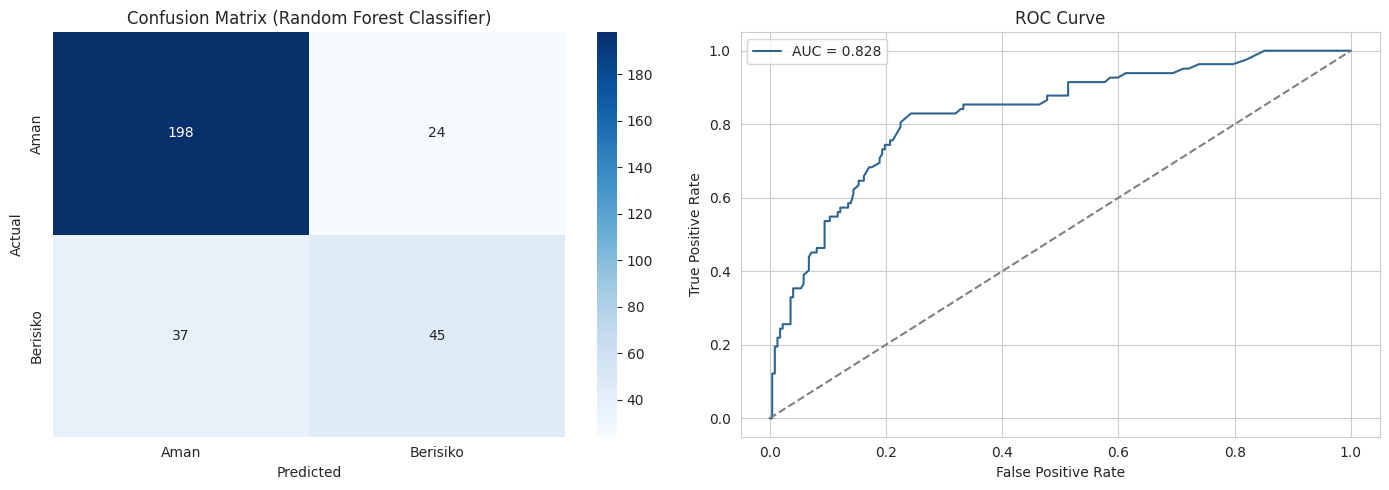

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Aman", "Berisiko"], yticklabels=["Aman", "Berisiko"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix ({best_model_name})")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
axes[1].plot(fpr, tpr, color="#2f6690", label=f"AUC = {roc_auc_score(y_test, y_proba_best):.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


### Feature Importance (Random Forest)

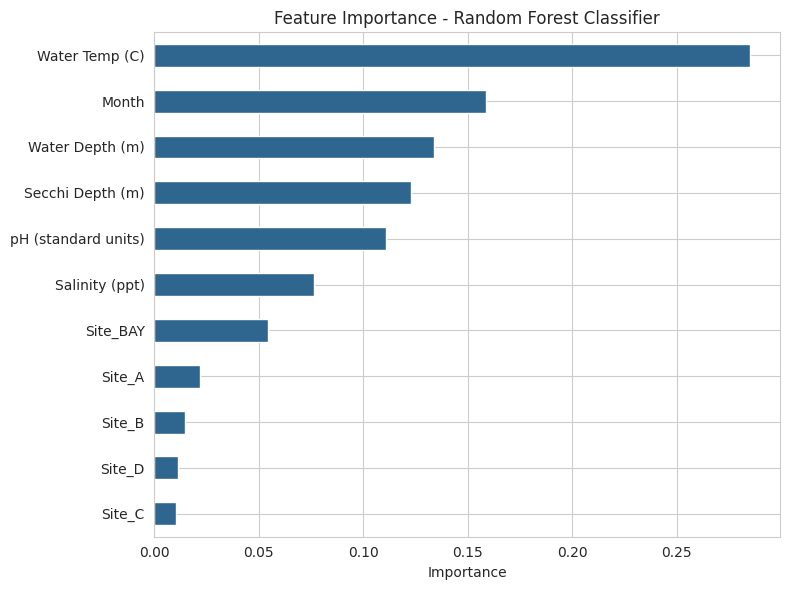

In [27]:
if best_model_name == "Random Forest Classifier":
    importances = pd.Series(models["Random Forest Classifier"].feature_importances_, index=X.columns)
else:
    importances = pd.Series(models["Random Forest Classifier"].feature_importances_, index=X.columns)

importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#2f6690")
plt.title("Feature Importance - Random Forest Classifier")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Catatan interpretasi:**
- Confusion matrix menunjukkan seberapa baik model membedakan kasus "Aman" dan "Berisiko" — untuk konteks lingkungan, **recall pada kelas "Berisiko" lebih krusial daripada akurasi keseluruhan**, karena melewatkan kasus berisiko (false negative) jauh lebih berbahaya secara ekologis daripada salah waspada (false positive).
- ROC-AUC memberi gambaran performa model di seluruh kemungkinan threshold, bukan hanya satu titik keputusan — berguna kalau nantinya ambang keputusan ingin disesuaikan (misal dibuat lebih sensitif demi menangkap lebih banyak kasus berisiko, dengan trade-off precision).
- Feature importance menunjukkan variabel mana yang paling berkontribusi terhadap prediksi risiko hipoksia — hasil ini bisa dipakai untuk memprioritaskan parameter mana yang paling penting diukur secara rutin di lapangan.


## 8. Kesimpulan & Insight

1. **Target klasifikasi dibangun dari label yang benar-benar terukur di lapangan** — baris dengan Dissolved Oxygen hasil imputasi sengaja tidak disertakan dalam modeling, sehingga label "Aman"/"Berisiko" mencerminkan observasi nyata, bukan estimasi statistik.
2. **~27% dari observasi yang punya data DO valid berada dalam kategori berisiko hipoksia (DO < 5 mg/L)** — proporsi yang cukup signifikan untuk sebuah program monitoring lingkungan, dan menunjukkan hipoksia bukan kejadian langka pada kawasan ini.
3. **Suhu air adalah salah satu prediktor terkuat risiko hipoksia**, sejalan dengan prinsip limnologi dasar bahwa air hangat menahan lebih sedikit oksigen terlarut — temuan ini juga konsisten dengan pola musiman pada tren tahunan.
4. **Model dievaluasi dengan metrik yang sesuai untuk data tidak seimbang** (precision, recall, F1, ROC-AUC dengan cross-validation stratified), bukan hanya akurasi — pendekatan yang tepat mengingat kelas minoritas ("Berisiko") adalah kelas yang paling penting untuk dideteksi secara akurat.
5. **Potensi pengembangan lanjutan:**
   - Menyesuaikan threshold keputusan model (bukan default 0.5) untuk memprioritaskan recall pada kelas "Berisiko", sesuai kebutuhan mitigasi risiko lingkungan.
   - Menambahkan data cuaca eksternal (curah hujan, kecepatan angin) yang diketahui memengaruhi tingkat oksigenasi air secara alami.
   - Mengembangkan klasifikasi 3 kelas (Aman/Waspada/Kritis) untuk memberi granularitas lebih pada tingkat urgensi tindakan.
